## 1. Midterm Memo: Czechia's Export Strategy and Future

In [1]:
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf
import statsmodels.api as sm
from typing import List
from IPython.display import display, Latex, Markdown
pd.options.mode.chained_assignment = None

## 2. Executive Summary

Czechia’s recent growth has been driven by capital accumulation rather than productivity gains. The country's export structure is slowly shifting more toward lead products and the arms industry. Since 1989, output per capita has risen slowly but steadily while total factor productivity has been largely flat, implying that the country risks staying in a middle‑income trap if it continues to rely on additional capital rather than innovation. Trade data also shows that Czechia’s strongest revealed comparative advantages in 2021 are not in the well-established automotive sector but in lead and related materials, textiles, and increasingly in arms and ammunition exports, signalling a possibly shifting role of Czechia within European defense supply chains.

Czechia should build on its existing strengths and establish itself within the defense ecosystem, whilst hedging against fragility in the multilateral trade systems and a pressing security situation in Europe. As such, Czechia should (i) invest in dual-use and defense-related R&D (increasing the possibility of positive TFP spillovers), (ii) strengthen integration with nearby large markets in relevant value chains, and (iii) deepen cultural connections with relevant (primarily regional) trading partners to increase resilience against a possible disintegration of the WTO system.

## 3. Background: Economic Performance

In [ ]:
pwt = pd.read_csv("https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-pwt.csv", sep=',')

In [67]:
alpha = 0.3

In [68]:
def add_series(df):
    df = df.copy()
    df["ynew"] = df["rgdpo"] / df["pop"]
    df["knew"] = df["cn"] / df["pop"]
    df["Anew"] = df["ynew"] / (df["knew"] ** alpha) / (df["hc"] ** (1 - alpha))
    df["lnynew"] = np.log(df["ynew"])
    df["lnknew"] = np.log(df["knew"])
    df["lnAnew"] = np.log(df["Anew"])
    return df

In [ ]:
pwt_cz = add_series(pwt[pwt["countrycode"] == "CZE"])
pwt_sk = add_series(pwt[pwt["countrycode"] == "SVK"])

pwt_cz_1980 = pwt_cz[pwt_cz["year"] >= 1980]
pwt_sk_1980 = pwt_sk[pwt_sk["year"] >= 1980]

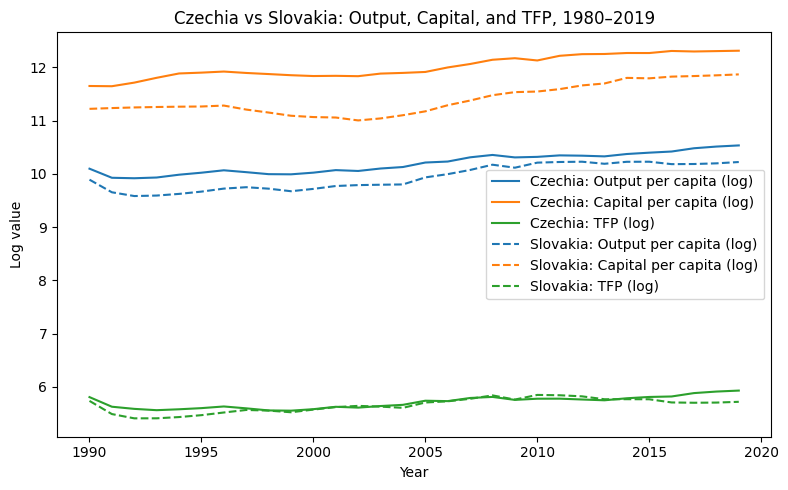

In [ ]:
plt.figure(figsize=(8,5))

line_y_cz, = plt.plot(pwt_cz_1980["year"], pwt_cz_1980["lnynew"],
                      label="Czechia: Output per capita (log)")
line_k_cz, = plt.plot(pwt_cz_1980["year"], pwt_cz_1980["lnknew"],
                      label="Czechia: Capital per capita (log)")
line_A_cz, = plt.plot(pwt_cz_1980["year"], pwt_cz_1980["lnAnew"],
                      label="Czechia: TFP (log)")

plt.plot(pwt_sk_1980["year"], pwt_sk_1980["lnynew"],
         linestyle="--", color=line_y_cz.get_color(),
         label="Slovakia: Output per capita (log)")
plt.plot(pwt_sk_1980["year"], pwt_sk_1980["lnknew"],
         linestyle="--", color=line_k_cz.get_color(),
         label="Slovakia: Capital per capita (log)")
plt.plot(pwt_sk_1980["year"], pwt_sk_1980["lnAnew"],
         linestyle="--", color=line_A_cz.get_color(),
         label="Slovakia: TFP (log)")

plt.xlabel("Year")
plt.ylabel("Log value")
plt.title("Czechia vs Slovakia: Output, Capital, and TFP, 1980–2019")
plt.legend()
plt.tight_layout()
plt.show()

Since the Velvet Revolution in 1989, Czechia's growth has been driven more by capital accumulation than by productivity gains. Czechia's TFP has not changed significantly, even though the country's GDP per capita and capital per capita increased over the years. Although Czechia's economy is often portrayed as a strong competitor to its former sister nation, Slovakia, for much of the country's history, TFP levels have been very similar. Only after 2015 did some divergence occur. In the future, as the country struggles out of the middle-income trap, it should focus on policies that could improve its TFP. Recent fiscal cuts in areas of R&D and education, however, suggest that the trap will not be overcome anytime soon.

## 4a. Export and Comparative Advantage Assessment

In [2]:
industryflows = pd.read_csv("https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-industryflows.csv", sep=',')

In [3]:
industryflowscze = industryflows[industryflows['iso_o'] == 'CZE']

In [4]:
industryflowscze21 = industryflowscze[industryflowscze['year'] == 2021]

In [73]:
industryflowscze00 = industryflowscze[industryflowscze['year'] == 2000]
industryflowscze21 = industryflowscze[industryflowscze['year'] == 2021]

In [74]:
industryflowscze00['value_tot'] = industryflowscze00['value'].sum()
industryflowscze00['value_wd_tot'] = industryflowscze00['value_wd'].sum()
industryflowscze00['sh_hs2'] = industryflowscze00['value'] / industryflowscze00['value_wd']
industryflowscze00['sh_wd'] = industryflowscze00['value_tot'] / industryflowscze00['value_wd_tot']
industryflowscze00['rca'] = industryflowscze00['sh_hs2'] / industryflowscze00['sh_wd']

industryflowscze21['value_tot'] = industryflowscze21['value'].sum()
industryflowscze21['value_wd_tot'] = industryflowscze21['value_wd'].sum()
industryflowscze21['sh_hs2'] = industryflowscze21['value'] / industryflowscze21['value_wd']
industryflowscze21['sh_wd'] = industryflowscze21['value_tot'] / industryflowscze21['value_wd_tot']
industryflowscze21['rca'] = industryflowscze21['sh_hs2'] / industryflowscze21['sh_wd']

In [75]:
rca_change = industryflowscze21[['hs2', 'rca']].merge(industryflowscze00[['hs2', 'rca']], on='hs2', suffixes=('_21', '_00'))
rca_change['rca_change'] = rca_change['rca_21'] - rca_change['rca_00']
rca_change = rca_change.sort_values('rca_change', ascending=False)

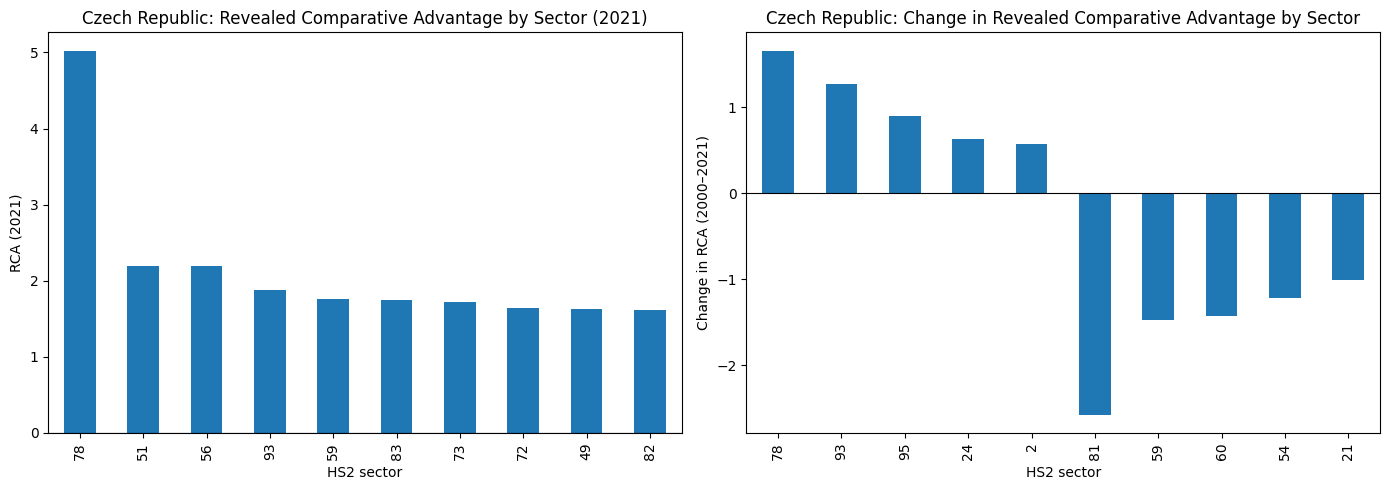

In [ ]:
top = rca_change.groupby('hs2')['rca_21'].last().sort_values(ascending=False).head(10)

top5 = rca_change.groupby('hs2')['rca_change'].last().sort_values(ascending=False).head(5)

bottom5 = rca_change.groupby('hs2')['rca_change'].last().sort_values().head(5)

sel = pd.concat([top5, bottom5]).reset_index().drop_duplicates(subset='hs2')

sel = sel.merge(rca_change, on=['hs2', 'rca_change'], how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

top.plot(x='hs2', y='rca_21', kind='bar', ax=ax1, legend=False)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel('HS2 sector')
ax1.set_ylabel('RCA (2021)')
ax1.set_title('Czech Republic: Revealed Comparative Advantage by Sector (2021)')

sel.plot(x='hs2', y='rca_change', kind='bar', ax=ax2, legend=False)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('HS2 sector')
ax2.set_ylabel('Change in RCA (2000–2021)')
ax2.set_title('Czech Republic: Change in Revealed Comparative Advantage by Sector')

plt.tight_layout()
plt.show()

Czechia’s strongest sectors in terms of revealed comparative advantage (RCA) were in lead and articles thereof (HS 78), wool and animal hair (HS 51), and wadding, felt, and nonwovens (HS 56), all of which have RCA above one. Between 2000 and 2021, RCA rose most strongly in lead and articles thereof (HS 78), arms and ammunition (HS 93), and toys, games, and sports equipment (HS 95), while it declined in base metals (HS 81), coated technical textiles (HS 59), and knitted or crocheted fabrics (HS 60). These findings are surprising considering Czechia's strong historical reliance on the automotive industry and production of heavy machinery and intermediary inputs therein. On the other hand, the strong RCA in lead and articles thereof and the rising importance of the arms and ammunition sector signal a complementary export pathway for Czechia in the defense industry. In the context of Europe's security situation, this data becomes highly important from a policy perspective.

## 4b. Imagining Global Trade without the WTO

In [7]:
gravity = pd.read_csv("https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-gravity.csv", sep=',')

In [79]:
gravitycze = gravity[(gravity['iso_o'] == 'CZE') & (gravity['year'] == 2020)]

In [80]:
gravitycze['log_value'] = np.log(gravitycze['value'] + 1)
gravitycze['log_distw'] = np.log(gravitycze['distw'])
gravitycze['log_gdp_d'] = np.log(gravitycze['gdp_d'])
gravitycze['log_scaled_sci_2021'] = np.log(gravitycze['scaled_sci_2021'])

In [ ]:
model1 = smf.ols('log_value ~ log_distw + log_gdp_d + contig + comlang_ethno +' \
            'comleg_posttrans + rta + wto_d + diplo_disagreement + log_scaled_sci_2021 + eu_d',
            data=gravitycze).fit(cov_type="HC1")

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     166.3
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           8.65e-72
Time:                        18:54:09   Log-Likelihood:                -237.56
No. Observations:                 155   AIC:                             495.1
Df Residuals:                     145   BIC:                             525.6
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -8.7725    

c:\Users\nepoz\yale\spring26\economics-for-global-affairs\economics-for-global-affairs\venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [82]:
beta_wto = model1.params['wto_d']
pct_change = np.exp(beta_wto) - 1
pct_change

np.float64(-0.13390819498851558)

The gravity model suggests that the standard trade-related variables matter a lot for Czech exports, while the estimated effect of the WTO disintegration is insignificant. In the 2020 data, exports increase as trade partner size increases and decrease as distance increases. A 1 per cent increase in distance is, on average, associated with 0.8 per cent lower exports, whilst a 1 per cent increase in a partner’s GDP is, on average, associated with 1.3 per cent higher exports (both results being highly significant). Moreover, higher social connectedness (log_scaled_sci_2021) is also highly significantly associated with increased trade, indicating that cultural ties are important for Czechia’s exporters. In contrast, the results for the WTO dummy variable are insignificant, although the point estimate shows a decrease of exports of about 13.4 per cent if everyone lost access to the WTO (see code for more details). Because Czechia’s trading partners mostly consisted of WTO members, there are insufficient counterfactuals in the data, leading to insignificant statistical results.

## 4c. Barriers to Trade

In a world without the WTO, Czechia should increase regional integration, improve cross-border connectivity, and enhance cultural ties with key partners. The gravity model shows that the size of the trading partner and the distance of Czechia from it are statistically significant determinants of export volumes. Therefore, policies that further integrate Czechia’s firms in nearby markets (especially within the EU) through robust regional trade agreements, common legal standards, and better infrastructure can protect against the WTO’s decline. Social connectedness could, for example, be influenced by promoting cultural exchange programs such as the Erasmus program. Because distance cannot be changed, streamlining logistics and other cross-border frictions becomes even more important if the multilateral trade system weakens.

## 5. Recommendations

Czechia should focus its trade strategy on the defense sector due to its relative strengths in lead and arms exports. The government should invest in scaling production in its existing defense-oriented value chains, whilst providing targeted R&D investments in defense-focused and dual-use technologies with the aim of possible TFP spillovers. Instead of leaving its legacy carmaking industry to die (or attempting a futile revival), Czechia should focus on reskilling its workforce and utilize existing capital to decrease upfront fixed costs in transitioning to a more arms-oriented nation.

At the same time, Czechia must shift its growth model, focused on capital accumulation, to a higher added value model. By promoting innovations in the latent European defense industry, Czechia could raise TFP by promoting research in advanced materials, unmanned vehicles, and digital systems with the hope of exporting these articles in the future. This could be achieved by promoting collaboration between Czech firms and research institutions, but also by building further intra-EU collaboration that could increase the interconnectedness with the country’s trading partners, thus resulting in increased resilience in cased of further attacks on the WTO.